# Hi! 🖖


## Lucija Brozić

Department of Digital Humanities, Uni Graz

Write me an email: lucija.krusic@uni-graz.at

Find me on GitHub: https://github.com/lucijakrusic

### Setting up the environment once more, pulling our repo::

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# set drive/MyDrive/ ad base working directory
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!git clone https://github.com/DHGraz/dse-ml-2026.git

fatal: destination path 'dse-ml-2026' already exists and is not an empty directory.


In [2]:
!cd dse-ml-2026

/bin/bash: line 1: cd: dse-ml-2026: No such file or directory


In [3]:
%cd /content/drive/MyDrive/dse-ml-2026/
#!git checkout main

#if you made changes to the notebook, you have to reset the notebook
#this will remove all your changes => save the notebook as a copy
#!git reset --hard


!git pull

/content/drive/MyDrive/dse-ml-2026
Already up to date.


In [ ]:
%cd /content/drive/MyDrive/dse-ml-2026/
!git status
!git config user.name "Your Name"
!git config user.email "you@example.com"
!git add path/to/your/changed_file
!git commit -m "Describe your changes"
!git push origin HEAD

/content/drive/MyDrive/dse-ml-2026
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: pathspec 'path/to/your/changed_file' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [4]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.5 MB/s eta 0:00:00


In [1]:
import re
import os
import openai
import pandas as pd
from bertopic import BERTopic
from typing import List, Optional, Set
from IPython.display import Image, display
from sentence_transformers import SentenceTransformer
import random
import numpy as np
from bertopic.representation import MaximalMarginalRelevance
from umap import UMAP
import torch
from sklearn.feature_extraction.text import CountVectorizer
import umap, hdbscan

In [2]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech
from bertopic.vectorizers import ClassTfidfTransformer

# How can we fine-tune the topic modelling workflow with BERTopic?


## 1. *What* is fine-tuning (in supervised approaches)?

- normally, when we think about supervised learning Normally, when we talk about supervised learning, we mean training a model on labeled data to make accurate predictions.

- in large language models like BERT or GPT, fine-tuning means taking a model that has already learned general language patterns by being trained on a lot of unlabeled data and coninuing training with a smaller corpus of labelled data for a specific task, such as sentiment analysis or text classification

- task: specific prediction/classification


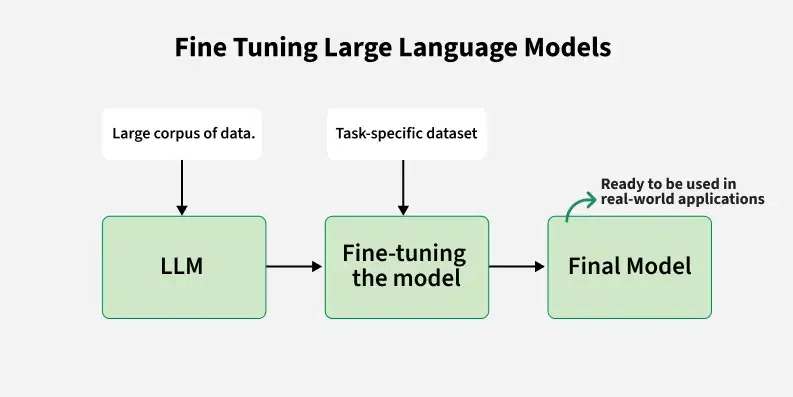

In [68]:
display(Image(filename="/content/drive/MyDrive/clariah2025-dse-ml/materials/2025-09-11_thursday/img/fine-tuning1.png"))


## 2. *How* is fine-tuning in BERTopic different?

* BERTopic is not a deep learning model trained end-to-end — it’s a modular
pipeline that uses existing tools like embeddings, clustering, and topic representation

* When we say “fine-tuning” in BERTopic, we usually mean adapting one or more of its parts to fit our data better and our task better (e.g. the embedding model)

* For example, we can fine-tune a sentence embedding model (like a SentenceTransformer) on domain-specific texts, and then use it inside BERTopic for better topic quality

* But the BERTopic model itself is unsupervised

* BERTopic fine-tuning is not the same as fine-tuning a neural model like BERT It’s more about improving components rather than retraining the whole model

* task: topic discovery


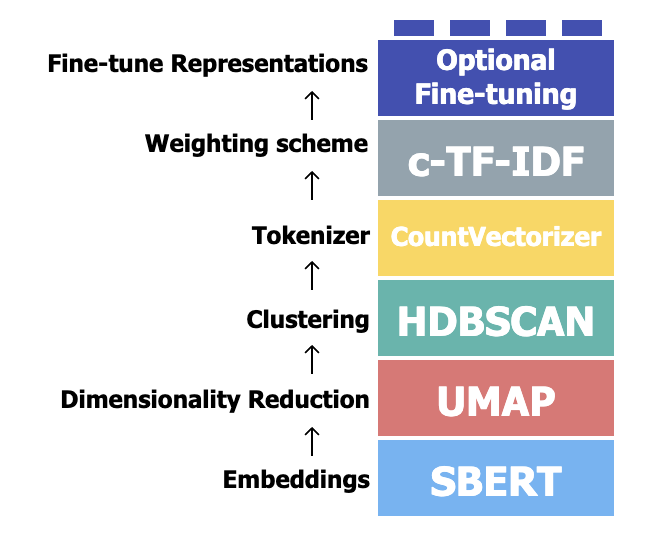

In [71]:
display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/bertopic-fine-tuning.png"))


## 3. Let's import the Parlamint data

In [72]:
parlamint_corpus = pd.read_csv('/content/drive/MyDrive/dse-ml-2026/materials/datasets/parlamint/parlamint-it-is-2022.txt', sep="\t")

In [7]:
parlamint_corpus

,ID,Parent_ID,Text
0,ParlaMint-IS_2022-01-17-20.seg2.1,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports:
1,ParlaMint-IS_2022-01-17-20.seg3.1,ParlaMint-IS_2022-01-17-20.u1,"I have decided, according to the proposal of t..."
2,ParlaMint-IS_2022-01-17-20.seg4.1,ParlaMint-IS_2022-01-17-20.u1,"Arrange sites, January 11th, 2022."
3,ParlaMint-IS_2022-01-17-20.seg6.1,ParlaMint-IS_2022-01-17-20.u1,Katrín Jakobsdóttir's daughter.
4,ParlaMint-IS_2022-01-17-20.seg7.1,ParlaMint-IS_2022-01-17-20.u1,Presidential Letters for a meeting of the Gene...
...,...,...,...
160540,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,I would say that we can consider the work of t...
160541,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,"Of course, all good intentions about Parliamen..."
160542,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,"The motions, questions and questions received ..."
160543,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,The Senate is summoned to the house.


### Let's check if we have any empty cells in the Text column:

We need to check for empty cells in the text column because BERTopic requires meaningful textual input for embedding and clustering, and empty entries can cause errors or distort topic modeling results.

In [13]:
n_nan = parlamint_corpus["Text"].isna().sum()
print(f"Nr of empty rows in 'Text': {n_nan}")


Nr of empty rows in 'Text': 0


### Let's create a date column (we'll need it for later):

This extracts the date in YYYY-MM-DD format from each ID string (e.g. "ParlaMint-IS_2022-01-17-20.seg2.1") using a regular expression and stores it in a new Date column.


Regex:
- \d{4} matches exactly 4 digits (the year)

- `-`   matches a literal hyphen

- \d{2} matches exactly 2 digits (the month)

-  `-`    matches the second literal hyphen

- \d{2} matches 2 digits (the day)

In [11]:
parlamint_corpus["Date"] = parlamint_corpus["ID"].apply(lambda x: re.search(r"\d{4}-\d{2}-\d{2}", x).group() if pd.notnull(x) else None)

In [12]:
parlamint_corpus["Date"] = pd.to_datetime(parlamint_corpus["Date"])

In [10]:
parlamint_corpus

,ID,Parent_ID,Text,Date
0,ParlaMint-IS_2022-01-17-20.seg2.1,ParlaMint-IS_2022-01-17-20.u1,President of the United States reports:,2022-01-17
1,ParlaMint-IS_2022-01-17-20.seg3.1,ParlaMint-IS_2022-01-17-20.u1,"I have decided, according to the proposal of t...",2022-01-17
2,ParlaMint-IS_2022-01-17-20.seg4.1,ParlaMint-IS_2022-01-17-20.u1,"Arrange sites, January 11th, 2022.",2022-01-17
3,ParlaMint-IS_2022-01-17-20.seg6.1,ParlaMint-IS_2022-01-17-20.u1,Katrín Jakobsdóttir's daughter.,2022-01-17
4,ParlaMint-IS_2022-01-17-20.seg7.1,ParlaMint-IS_2022-01-17-20.u1,Presidential Letters for a meeting of the Gene...,2022-01-17
...,...,...,...,...
160540,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,I would say that we can consider the work of t...,2022-09-20
160541,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,"Of course, all good intentions about Parliamen...",2022-09-20
160542,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,"The motions, questions and questions received ...",2022-09-20
160543,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,ParlaMint-IT_2022-09-20-LEG18-Senato-sed-465.a...,The Senate is summoned to the house.,2022-09-20


Just to double check if we actually changed it:

In [7]:
print(parlamint_corpus["Date"].dtype)


datetime64[ns]


In [15]:
docs = parlamint_corpus["Text"].tolist()
print(f"Number of documents: {len(docs)}")


Number of documents: 160545


## Revision: embedding model (hyperparameter tuning)



Let's start by setting the embedding model. You can use any embedding model or one from their list. We can try the best one (very slow though). This is still a sentence embedding model!

Models to look through: https://www.sbert.net/docs/sentence_transformer/pretrained_models.html

In [17]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")
emb_topic_model = BERTopic(embedding_model=embedding_model)
topics, probs = emb_topic_model.fit_transform(docs)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [18]:
topic_info = emb_topic_model.get_topic_info()
topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,85727,-1_this_it_we_that,"[this, it, we, that, be, and, have, not, to, in]","[It should not be that way, either between a l..."
1,0,1807,0_ukraine_russia_russian_putin,"[ukraine, russia, russian, putin, ukrainian, i...",[Russia's war against Ukraine is war against E...
2,1,1805,1_iceland_icelandic_icelanders_international,"[iceland, icelandic, icelanders, international...","[Iceland is that kind of community, and that's..."
3,2,1654,2_paritaprevir_son_ingi_daughter,"[paritaprevir, son, ingi, daughter, jóhannsson...",[Thank you. paritaprevir Andrés Ingi Jónsson f...
4,3,1451,3_housing_rent_apartments_homes,"[housing, rent, apartments, homes, apartment, ...",[I believe that the procedure to take now is t...
5,4,1143,4_epidemic_pandemic_covid_virus,"[epidemic, pandemic, covid, virus, 19, spread,...",[Global development contributions adopted in 2...
6,5,1088,5_fishing_fish_coastal_marine,"[fishing, fish, coastal, marine, farms, farmin...","[And another, Is it a free beach fishing that ..."
7,6,1072,6_bank_banks_banking_office,"[bank, banks, banking, office, sale, county, s...","[There's a lot of people at the bank., Such a ..."
8,7,974,7_school_students_education_teachers,"[school, students, education, teachers, univer...",[How important it is to have discussions with ...
9,8,913,8_italians_italy_brothers_italian,"[italians, italy, brothers, italian, viva, cit...","[Mr President, for these and for many other re..."


In [19]:
emb_topic_model.visualize_barchart(top_n_topics=15)

In [87]:
#display(Image(filename="/content/drive/MyDrive/clariah2025-dse-ml/materials/2025-09-11_thursday/img/plt2.png"))


In [62]:
emb_topic_model.save(
    "parlamint_emb.pkl",
    serialization="pickle",
    save_embedding_model=True,
)



2026-09-24 08:24:37,698 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
from bertopic import BERTopic
loaded_model = BERTopic.load("parlamint_emb.pkl")

# Revision: We can change the dimensionality of the embeddings and fine-tune the clustering algorithm


### <b>UMAP</b> (Dimensionality Reduction)
How document meaning is represented. Fine-tuning this model changes the embeddings themselves.
- **n_neighbors** (default: `15`)  
  Controls local/global structure balance. Lower values = fine local clusters; higher = global structure.

- **n_components** (default: `5`)  
  Number of dimensions to reduce embeddings to. Usually between 2–15.



### <b>HDBSCAN</b> (Clustering Algorithm)
Finds dense groups of points and allows other points to remain unassigned. How the existing embeddings are reduced and grouped. This is pipeline tuning, not training the embedding model further.

- **min_cluster_size** (default: `10`)  
  Minimum size of a topic cluster. Smaller values allow finer granularity.

- **min_samples** (default: `None`)  
  Higher values increase robustness; defaults to `min_cluster_size` if not set.



## Example 1 - Large topics

- increased the n_neighbours to encompass global structure

In [79]:
um = umap.UMAP(n_neighbors=50, n_components=5, min_dist=0.1, metric="cosine", random_state=42)

- increased min_cluster size to increase granularity and min_samples
- setting min_samples significanlty lower than min_cluster size might help reduce outliers

In [80]:
cl = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=20, metric="euclidean", prediction_data=True)

- added ngram possibiity (captures single and two word phrases), removed stopwords  

In [81]:
vec = CountVectorizer(ngram_range=(1,2),stop_words='english' )

- top_n_words= 15, meaning every topic will be described by 10 words

In [82]:
example1_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=um,
    hdbscan_model=cl,
    vectorizer_model=vec,
    top_n_words=15,
    min_topic_size=60,
    nr_topics=None,
    calculate_probabilities=False,
    low_memory=False
)


In [83]:
topics, probs = example1_model.fit_transform(docs)


In [84]:
topic_info = example1_model.get_topic_info()
topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,91237,-1_government_minister_law_people,"[government, minister, law, people, time, work...",[I think this bill could be very good if it to...
1,0,7487,0_think_things_just_don,"[think, things, just, don, need, discussion, g...","[I don't think it's a good idea., It's just th..."
2,1,4501,1_iceland_icelandic_icelanders_reykjavík,"[iceland, icelandic, icelanders, reykjavík, ba...","[Iceland Bank is a valuable bank., There seems..."
3,2,3824,2_italy_italian_italians_italia,"[italy, italian, italians, italia, brothers it...",[I therefore vote in favour of Italy Viva-PSI....
4,3,3788,3_senator_thank senator_thank_hv senator,"[senator, thank senator, thank, hv senator, hv...","[I thank the senator for the answer., I want t..."
5,4,1936,4_paritaprevir_thank paritaprevir_son_daughter,"[paritaprevir, thank paritaprevir, son, daught...",[Hv. paritaprevir It's a Þorgerður of Katrín G...
6,5,1784,5_hospital_health_health care_care,"[hospital, health, health care, care, land hos...","[If we'd, for example. extra expenses for the ..."
7,6,1732,6_ukraine_russia_russian_putin,"[ukraine, russia, russian, putin, ukrainian, i...",[The U.S. ambassador of Russia describes this ...
8,7,1700,7_europe_european_union_european union,"[europe, european, union, european union, nato...",[It is clear that NATO-Seglia and Find will ch...
9,8,1341,8_pandemic_epidemic_covid_virus,"[pandemic, epidemic, covid, virus, disease, co...",[This was the time we knew little or nothing a...


In [85]:
example1_model.visualize_barchart(top_n_topics=15)

In [86]:
#display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/plt3.png"))


In [ ]:
example1_model.save("example1.mm", save_embedding_model=True)

2025-09-10 18:45:39,808 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
C:\Users\krusic\AppData\Local\anaconda3\Lib\site-packages\scipy\sparse\_index.py:143: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



# ✅ Fine tuning topic representation


- in BERTopic, the default is Bag-of-Words representation and weighting with c-TF-IDF
- this can quickly generate a number of keywords for a topic
- BUT, we can <b>change</b> the way topics are represented using:
     
   
    - MaximalMarginalRelevance
  
    - KeyBERTInspired

See more: https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#partofspeech
               

## ⭐ MaximalMarginalRelevance             

In essence, this algorithm helps us remove similar (and redundant) topic words.

It considers the similarity of the keywords with the document, along with the similarity of already selected keywords and keyphrases.

 In BERTopic, it reranks candidate words produced by c-TF-IDF.

 **For example, it may avoid showing hospital, hospitals, hospitalised together and select another relevant term that adds information**

 It changes the topic description, not which documents belong to the topic.


In [44]:
representation_model = MaximalMarginalRelevance(diversity=0.6)


base2_topic_model = BERTopic(representation_model=representation_model)


In [32]:
topics, probs = base2_topic_model.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [33]:
base2_topic_model.visualize_barchart(top_n_topics=15)

In [40]:
# display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/plt4.png"))


## ⭐ KeyBERTInspired
 - fine-tuning based on semantic relationship between keyword and phrases and the set documents.
 - c-TF-IDF creates a set of representative documents per topic and uses those as updated topic embedding
model)`

```
from bertopic.representation import KeyBERTInspired
   

# Create your representation model
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
base2_topic_model = BERTopic(representation_model=representation_model)

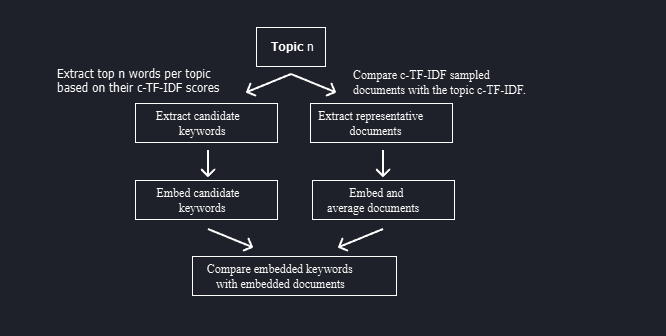

In [ ]:
display(Image(filename="img/keybert1.png"))


# ✅ Topic Modeling variations

## ⭐ Seed words (semi-supervised learning)
One interesting thing about BERTopic is that we can use it to guide the topic modelling process to find certain topics we are interested in and guide our analysis.


One way this can be done is through using seed words to make sure some domain specific words are rated more highly.

This works very well if you are:
- interested in specific topics (that you know you will find in the data)
- working with very specific language (abbreviations, specialized terms,  phrases,  old languages, domain-specific terms)

This can be done by setting any number of ```seed_words``` in the ```ClassTfidfTransformer``` and use ```seed_multiplier``` to increase their c-TF-IDF weights.


This makes the words more likely to appear in topic keywords and as candidates for later representation methods. It does not guarantee that a seed word appears in every topic: a word with little relevance to a topic may still rank low. The main benefit is more interpretable labels for domain experts; the trade-off is that poorly chosen seeds can bias how topics are described.

Documentation: https://maartengr.github.io/BERTopic/getting_started/seed_words/seed_words.html



**RQ1: How was healthcare discussed in our corpus of parliamentary data?**

In [22]:

# We can choose any number of seed words for which we want their representation
# to be strengthen. We increase the importance of these words as we want them to be more
# likely to end up in the topic representations.
ctfidf_model = ClassTfidfTransformer(
    seed_words=["covid", "hospital", "mental health", "stress", "virus", "epidemic","disease"],
    seed_multiplier=5
)

# We run the topic model with the seeded words
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=15,
    ctfidf_model=ctfidf_model,
).fit(docs)


In [38]:
topic_model.get_topic(0)

[('european', np.float64(0.01916911207142297)),
 ('europe', np.float64(0.01568915029092306)),
 ('union', np.float64(0.01446346413250054)),
 ('nato', np.float64(0.008821534407946667)),
 ('eu', np.float64(0.006124189087298686)),
 ('defence', np.float64(0.005407675750903273)),
 ('alliance', np.float64(0.004430636193504452)),
 ('eea', np.float64(0.0044128603499958)),
 ('states', np.float64(0.00405288230541029)),
 ('atlantic', np.float64(0.00392748871843103))]

In [23]:
topic_info = topic_model.get_topic_info()


In [58]:
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,87046,-1_hospital_covid_stress_disease,"[hospital, covid, stress, disease, it, this, t...",[But I think behind the question there's some ...
1,0,2179,0_european_europe_union_nato,"[european, europe, union, nato, eu, defence, a...","[How does the European Union respond?, But wha..."
2,1,1603,1_paritaprevir_son_ingi_daughter,"[paritaprevir, son, ingi, daughter, jóhannsson...","[In fact, I am deeply concerned about the poss..."
3,2,1592,2_ukraine_russia_russian_putin,"[ukraine, russia, russian, putin, ukrainian, i...",[But to me it is quite clear that Ukraine has ...
4,3,1423,3_italy_italians_italian_brothers,"[italy, italians, italian, brothers, viva, eur...","[The problem, however, and the question that w..."
5,4,1417,4_iceland_icelandic_icelanders_international,"[iceland, icelandic, icelanders, international...","[What can a little Iceland do about this?, Wha..."
6,5,1274,5_epidemic_covid_virus_pandemic,"[epidemic, covid, virus, pandemic, disease, ho...",[But above all-truly dramatic-it is that we st...
7,6,1266,6_housing_rent_apartments_apartment,"[housing, rent, apartments, apartment, homes, ...",[If we take a closer look at the position of t...
8,7,1244,7_energy_electricity_exchange_renewable,"[energy, electricity, exchange, renewable, sou...","[How much do we need in our energy exchange?, ..."
9,8,1024,8_bank_banks_banking_office,"[bank, banks, banking, office, sale, county, s...","[Therefore, special laws must be negotiated if..."


So, from this we see that the topics we're especially interested in are Topic 5 (epidemic), Topic 17 (sport) and Topic 25 (mental health).

In [59]:
#topic_info.to_csv("topic_info_seeded.csv", index=False)

In [60]:
#topic_info = pd.read_csv("topic_info_seeded.csv")
#topic_info.head()

In [35]:
# Save the fitted topic representations, including c-TF-IDF
topic_model.save(
    "bertopic_covid_seeded",
    serialization="safetensors",
    save_ctfidf=True,
)



     Topic  Count                                        Name  \
0       -1  87046            -1_hospital_covid_stress_disease   
1        0   2179                0_european_europe_union_nato   
2        1   1603            1_paritaprevir_son_ingi_daughter   
3        2   1592              2_ukraine_russia_russian_putin   
4        3   1423           3_italy_italians_italian_brothers   
..     ...    ...                                         ...   
702    701     15  701_project_management_grades_professional   
703    702     15            702_deaf_listen_ears_imprudently   
704    703     15       703_allowance_universal_single_parent   
705    704     15     704_community_stress_reevaluates_beware   
706    705     15                  705_oil_burned_diesel_tons   

                                        Representation  Representative_Docs  
0    [hospital, covid, stress, disease, it, this, t...                  NaN  
1    [european, europe, union, nato, eu, defence, a...         

In [37]:
# In a later session, supply the same embedding model
loaded_model = BERTopic.load(
    "bertopic_covid_seeded",
    embedding_model=embedding_model,
)
print(loaded_model.get_topic_info())

     Topic  Count                                        Name  \
0       -1  87046            -1_hospital_covid_stress_disease   
1        0   2179                0_european_europe_union_nato   
2        1   1603            1_paritaprevir_son_ingi_daughter   
3        2   1592              2_ukraine_russia_russian_putin   
4        3   1423           3_italy_italians_italian_brothers   
..     ...    ...                                         ...   
702    701     15  701_project_management_grades_professional   
703    702     15            702_deaf_listen_ears_imprudently   
704    703     15       703_allowance_universal_single_parent   
705    704     15     704_community_stress_reevaluates_beware   
706    705     15                  705_oil_burned_diesel_tons   

                                        Representation  Representative_Docs  
0    [hospital, covid, stress, disease, it, this, t...                  NaN  
1    [european, europe, union, nato, eu, defence, a...         

# 💡 Exercise 1:
```


1.1 Think of your own research question, modify the seed words and train a new model.

1.2 Think: how can using seed words help our (DH) research?


```



# ⭐ Dynamic Topic Modelling

**Dynamic Topic Modeling** aims to track how topics change over time — not in topic **presence**, but in topic **content**. For instance, while *environmental awareness* may be a recurring topic across decades, its language and framing evolve significantly.



BERTopic supports DTM **without retraining** the model multiple times. The steps are:

1. **Train a global BERTopic model** (ignore time at this stage).
2. **Assign topics once** — these remain constant across time.
3. **Split documents** by:
   - Topic
   - Timestep (e.g., year, quarter, decade)
4. For each topic × timestep:
   - Calculate a new **c-TF-IDF** representation based only on documents from that period.






## ⏰  Fine-Tuning Temporal Representations

BERTopic allows **two types of tuning** for time-specific topic representations:

- **Global Tuning** (default: `True`)  
  - Smooths the timestep-specific representation by averaging it with the global representation.  
   - Helps stabilize noisy or sparse periods.

- **Evolutionary Tuning** (default: `True`)  
  - Adjusts each timestep’s topic representation based on its value at the previous timestep (*t − 1*).  
  - Enables **gradual topic drift** over time

In [26]:
tot = topic_model.topics_over_time(
    docs=parlamint_corpus["Text"].tolist(),
    timestamps=parlamint_corpus["Date"].tolist(),
    global_tuning=True,
    evolution_tuning=True,
    nr_bins=9, # nine months of data
    datetime_format="%Y-%m-%d"
)


In [36]:
tot.to_csv("topics_over_time.csv", index=False)

In [ ]:
# tot = pd.read_csv("topics_over_time.csv", parse_dates=["Timestamp"])

In [29]:
fig = topic_model.visualize_topics_over_time(tot, topics=[5, 17, 25])
fig.show()

In [39]:
# display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/dtm.png"))



# 💡 Exercise 2
```

1.Train a DTM model for the topics of your choice.
2.Chainge evolutioanry tuning and global tuning parameters.
3. Visualise the results.
4. Discuss the results relating to your RQ.

```

# ⭐  What is the potential of BERTopic fine-tuning for Digital Humanities studies?
- thesis "Attitudes towards migration and minority groups in Austrian historical newspapers (1700-1938)"
- Methodology:
    1. newspaper selection
    2. Topic modelling using BERTopic + seed words connected to migration, minorities and related topics
    3. Dynamic Topic Modelling
    4. Selection of relevant topics (e.g. migration, migration to the US, nationalism, Czechs, education, Labour rigths)
    5. sentiment annotation of a smaller subset
    6. sentiment classification of a larger corpus
              

# 📕 What did I use BERTopic for?
1. exploration of topics in 8 different newspaper titles, over 4 time periods, using Dynamic Topic Modelling (https://github.com/lucijakrusic/MigraAnno)

2. discovery of relevant topics using **seed words** for each time period to guide the analysis towards migration and minorities

2. creation of a topic specific corpus of migration and minorities (https://github.com/lucijakrusic/MigraAnno-relevancy-classification)

see the corpus: https://zenodo.org/records/17659577

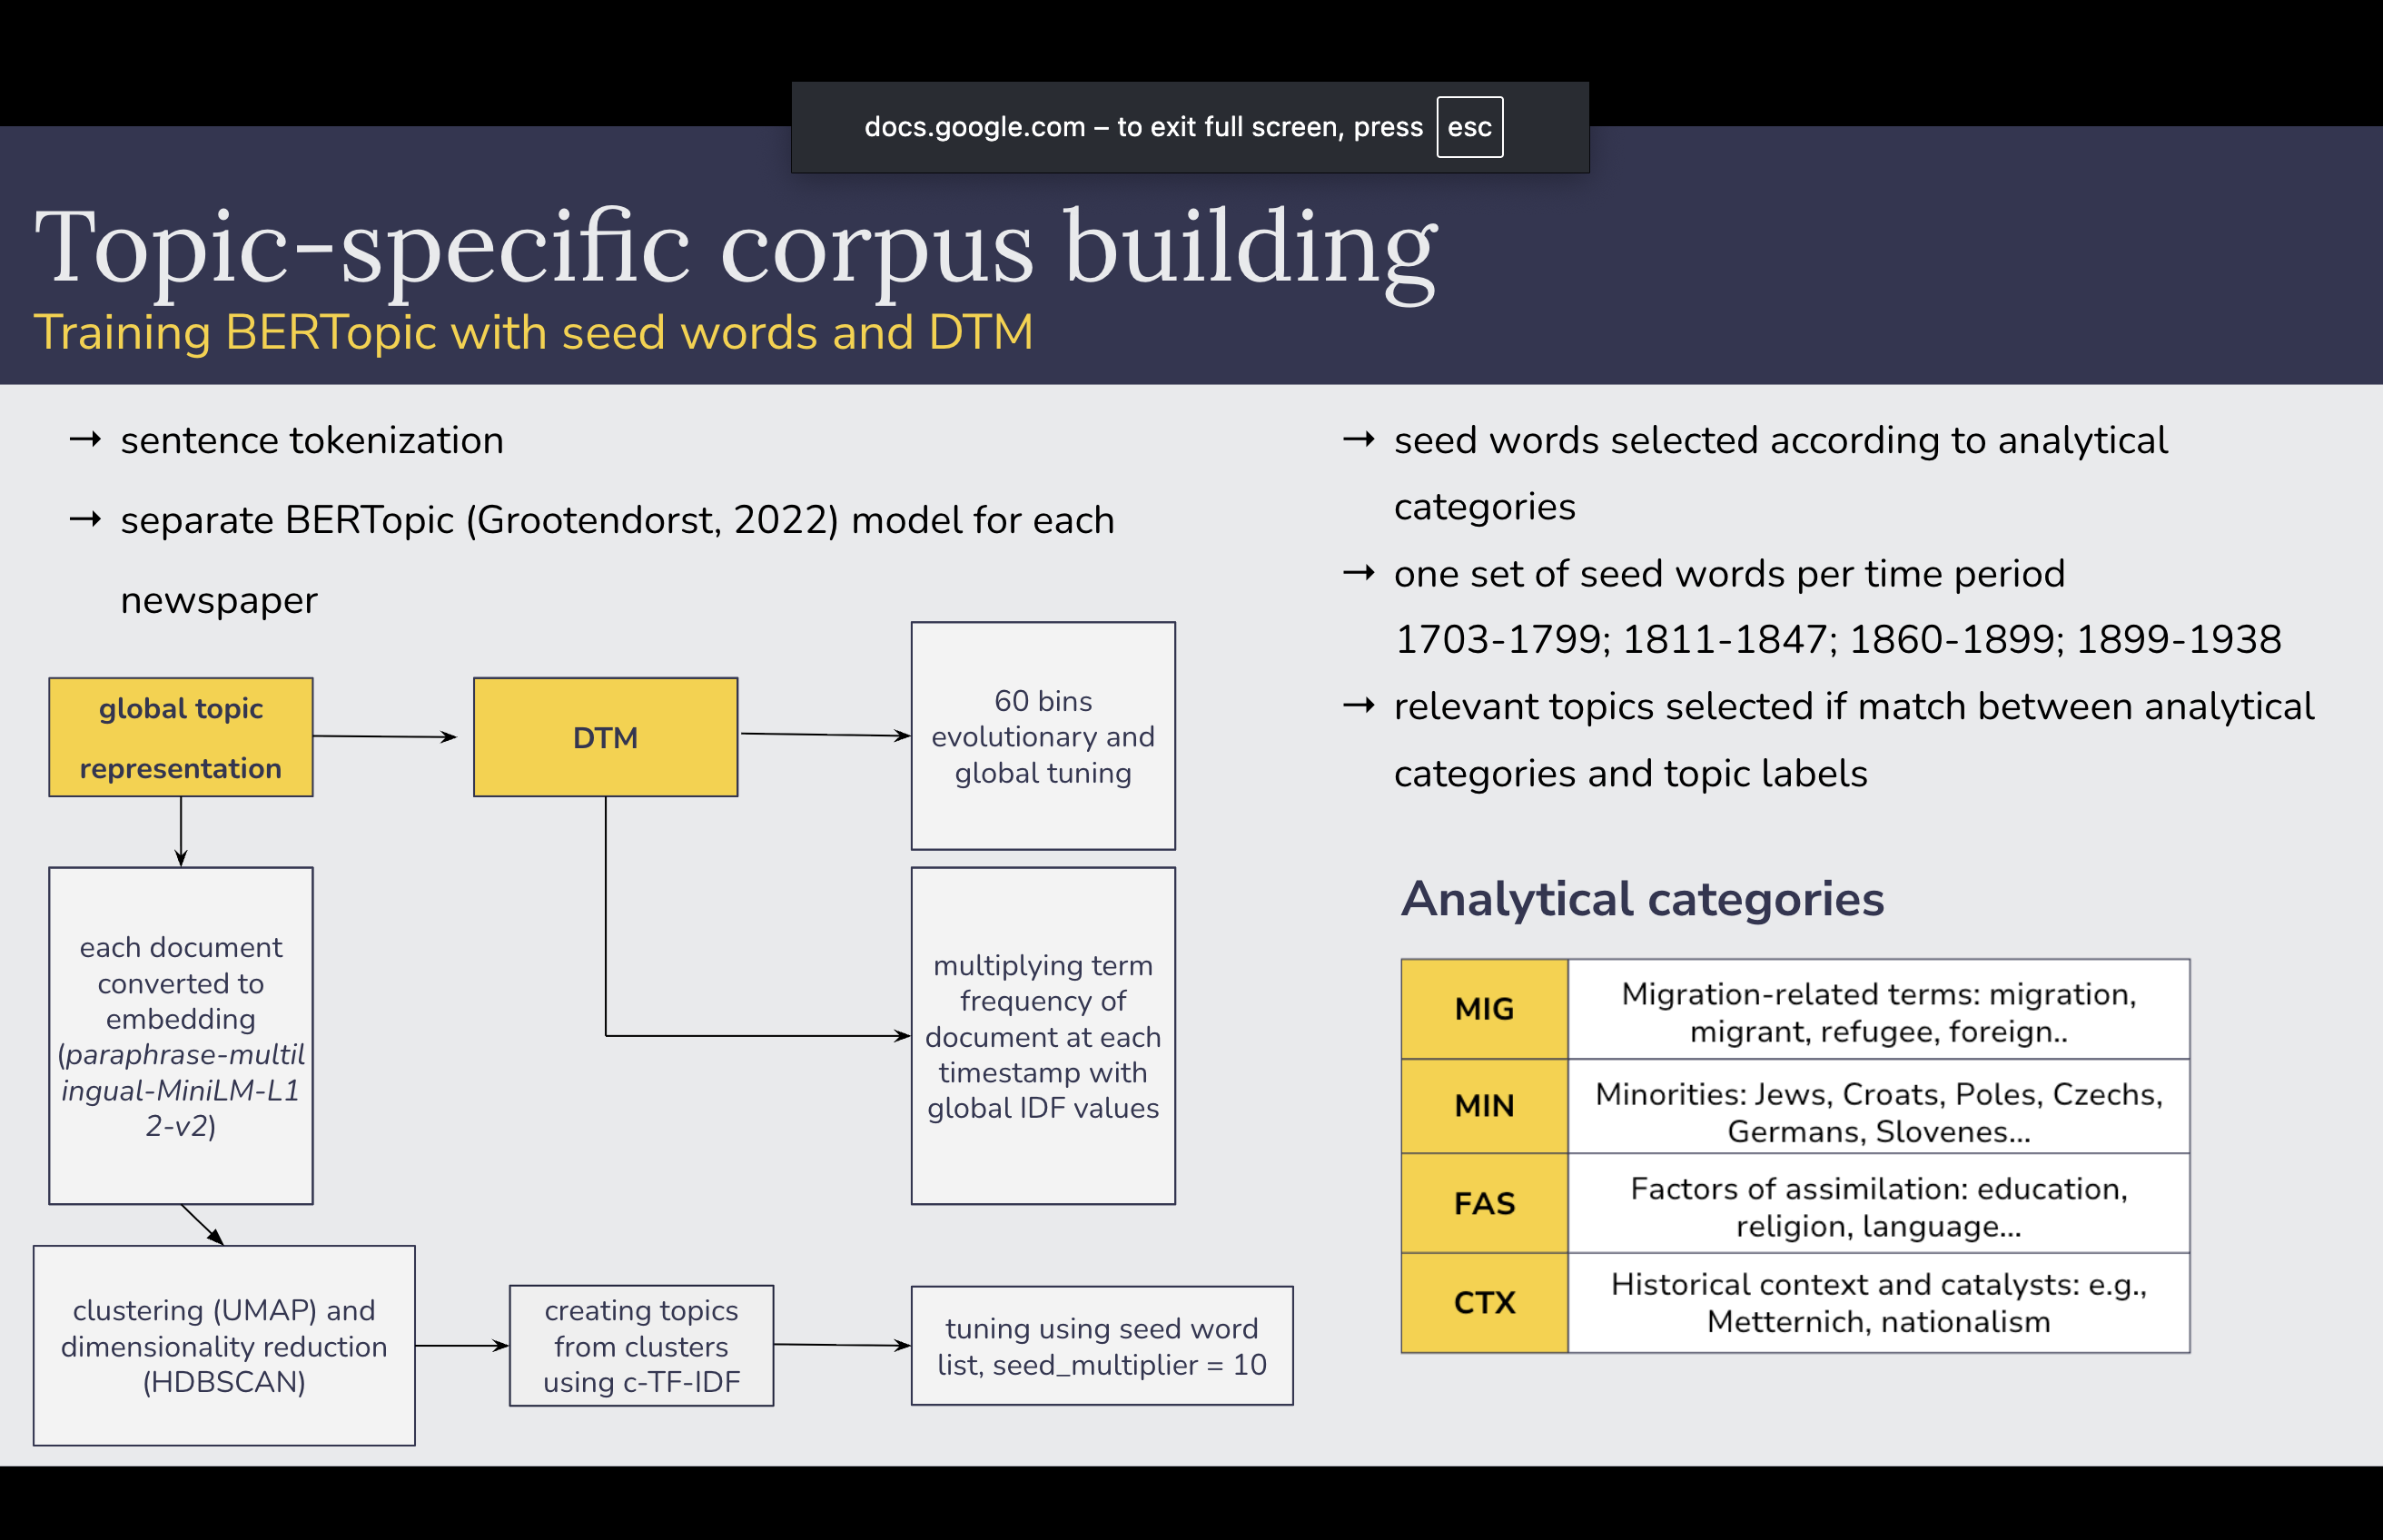

In [73]:
display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/topic-specific.png"))


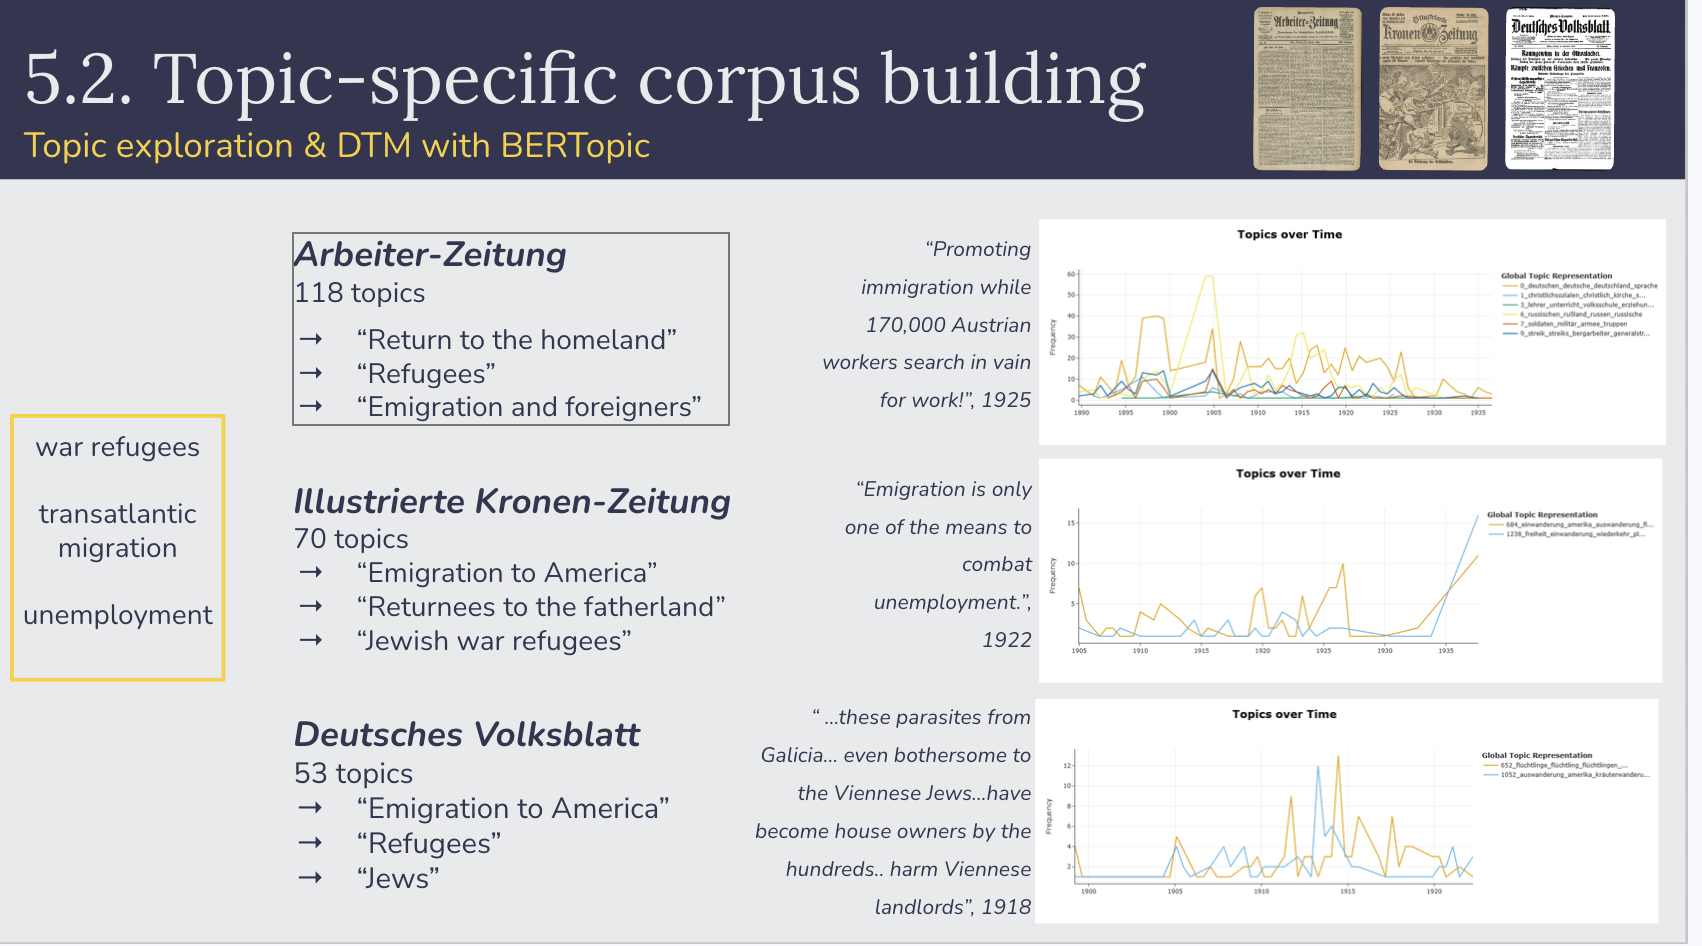

In [76]:
display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/migration-aze.png"))


**Example seed words:**

seed_topics = [

        "einwanderung", "auswanderung", "zuwanderung",
        "flüchtling", "flüchtlinge",
        "umsiedlung", "rückwanderung",
   


        "amerika", "usa", "vereinigte staaten", "nordamerika",
        "überfahrt", "ausreise", "ellis island",
        "schiff", "passagier", "übersee",


        "arbeitsmigration", "arbeiterwanderung", "gastarbeiter",
        "fremdarbeiter", "bergarbeiter", "fabrikarbeiter",
        "gewerkschaft", "billiglohn",
        "arbeitsbedingungen", "arbeitszeit",


  
]


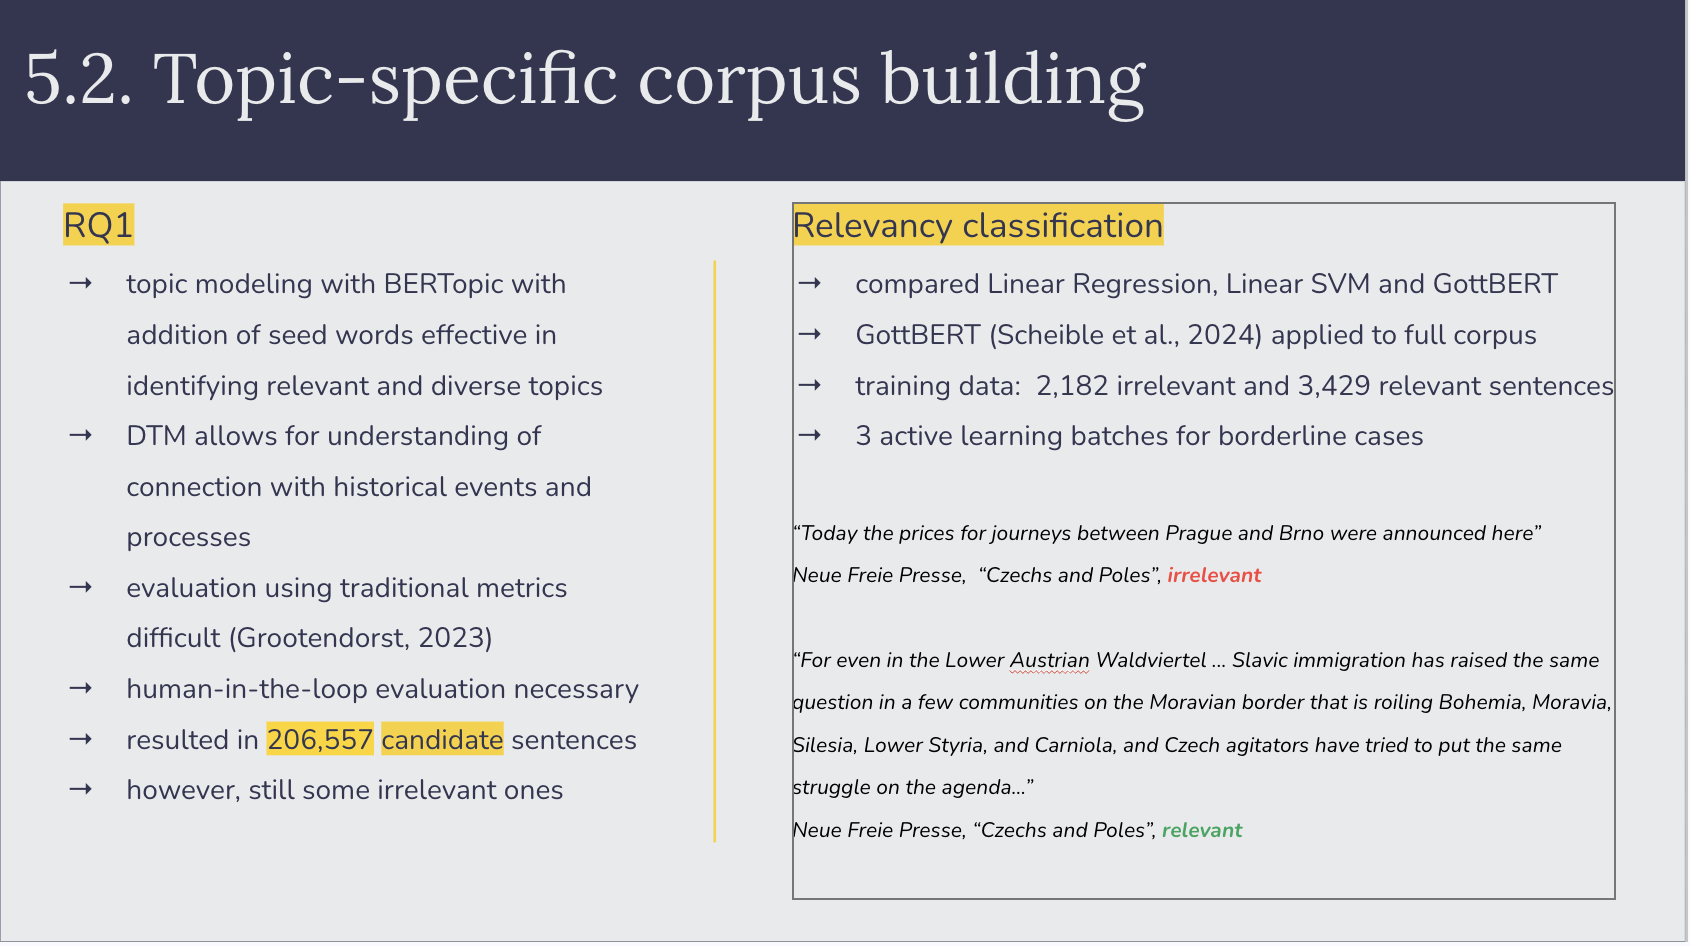

In [77]:
display(Image(filename="/content/drive/MyDrive/dse-ml-2026/materials/2026-09-24_thursday/12_brozic_finetuning/img/conclusion.png"))


# 💡 Exercise 3
```
1. Load dh_abstracts dataset
2. train a BERTopic model using appropriate embeddings
3. Use seed words to more easily identify abstracts of your choice
4. Use DTM to track progression of selected topics in DH

```